##**Plantilla**

In [1]:
import pandas as pd

ruta = "https://raw.githubusercontent.com/VillaltaE/netflix_churn/refs/heads/main/netflix_customer_churn.csv"
df = pd.read_csv(ruta)

model_cols = [
    "subscription_type",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day",
    "payment_method"
]

X = df[model_cols]
y = df["churned"]

X.head(), y.value_counts(normalize=True)


(  subscription_type  watch_hours  last_login_days  monthly_fee  \
 0             Basic        14.73               29         8.99   
 1          Standard         0.70               19        13.99   
 2          Standard        16.32               10        13.99   
 3           Premium         4.51               12        17.99   
 4          Standard         1.89               13        13.99   
 
    number_of_profiles  avg_watch_time_per_day payment_method  
 0                   1                    0.49      Gift Card  
 1                   5                    0.03      Gift Card  
 2                   2                    1.48         Crypto  
 3                   2                    0.35         Crypto  
 4                   2                    0.13         Crypto  ,
 churned
 1    0.503
 0    0.497
 Name: proportion, dtype: float64)

##**Importar lo necesario**

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier as RandomForest
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt



##**Definir columnas por tipo**



In [3]:
categorical_cols = ["subscription_type","payment_method"]
numeric_cols = [
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]


##**Crear el preprocesador**

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


##**Train/Test split (80/20)**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((4000, 7), (1000, 7))

##**Armar el pipeline**

In [6]:
#Se usaran los modelos "Logistic Regression" y "Random Forest"
lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForest())
])

#**Linear Regression**

##**Entrenar**

In [7]:
lr.fit(X_train, y_train)



Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['subscription_type',
                                                   'payment_method']),
                                                 ('num', 'passthrough',
                                                  ['watch_hours',
                                                   'last_login_days',
                                                   'monthly_fee',
                                                   'number_of_profiles',
                                                   'avg_watch_time_per_day'])])),
                ('model', LogisticRegression(max_iter=1000))])

##**Evaluar**

### Reporte de clasificación

In [8]:
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.91      0.88      0.89       497
           1       0.88      0.91      0.90       503

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



In [9]:
#Crear copia de y_pred y llamrla y_pred_lr
y_pred_lr = y_pred

## Matriz de confusión

In [10]:
print(confusion_matrix(y_test, y_pred_lr))

[[436  61]
 [ 45 458]]


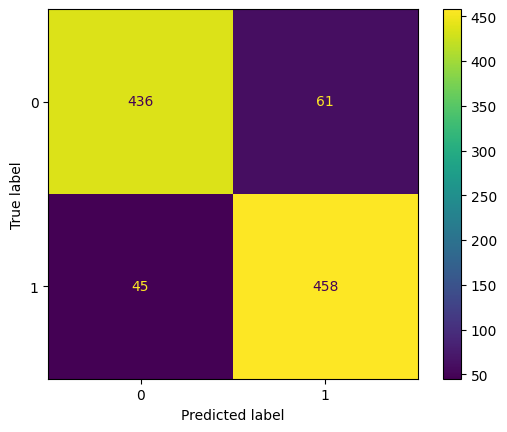

In [11]:
visualizacion = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_lr))
visualizacion.plot();

### Precisión

In [12]:
print(accuracy_score(y_test, y_pred_lr))

0.894


#**Random Forest**

##**Entrenar**

In [13]:
rf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['subscription_type',
                                                   'payment_method']),
                                                 ('num', 'passthrough',
                                                  ['watch_hours',
                                                   'last_login_days',
                                                   'monthly_fee',
                                                   'number_of_profiles',
                                                   'avg_watch_time_per_day'])])),
                ('model', RandomForestClassifier())])

##**Evaluar**

### Reporte de clasificación

In [14]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       497
           1       0.99      0.99      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [15]:
#crear copia de y_pred y llamarla y_pred_rf
y_pred_rf = y_pred

##Matriz de confusión

In [16]:
print(confusion_matrix(y_test, y_pred_rf))

[[493   4]
 [  5 498]]


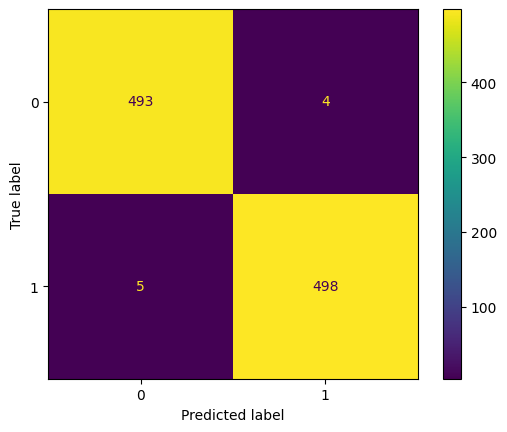

In [17]:
visualizacion = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_rf))
visualizacion.plot();

### Precisión

In [18]:
print(accuracy_score(y_test, y_pred_rf))

0.991


### Curva ROC ambos modelos, comparando con uno sin habilidades

In [19]:
#Gráfico alternativo de la curva ROC
# Generar un predictor sin habilidad
ns_probs = [0 for _ in range(len(y_test))]

# Calculo de la métrica auc
#Predictor sin habilidad
ns_auc = roc_auc_score(y_test, ns_probs)
#Predictor Linear Regression
lr_auc = roc_auc_score(y_test, y_pred_lr)
#Predictor Random Forest
rf_auc = roc_auc_score(y_test, y_pred_rf)

# Cáculo de la curva roc
ns_fpr, ns_tpr, t = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, t = roc_curve(y_test, y_pred_lr)
rf_fpr, rf_tpr, t = roc_curve(y_test, y_pred_rf)

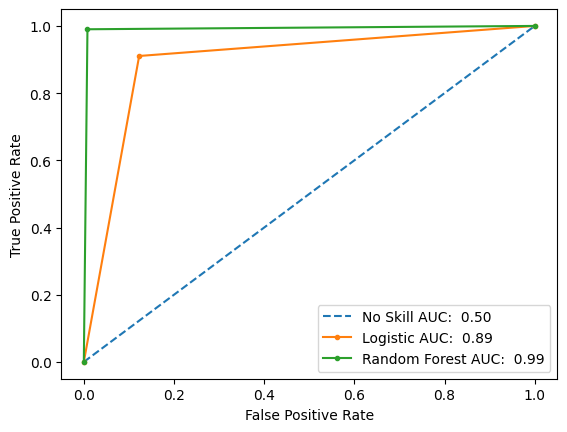

In [20]:

# Calculate rf_auc since it was not defined before
rf_auc = roc_auc_score(y_test, y_pred_rf)
lr_auc = roc_auc_score(y_test, y_pred_lr)

#Gráfico de la curva ROC
plt.plot(ns_fpr, ns_tpr, linestyle='--', label=f'No Skill AUC: {ns_auc: .2f}')
plt.plot(lr_fpr, lr_tpr, marker='.', label=f'Logistic AUC: {lr_auc: .2f}')
plt.plot(rf_fpr,rf_tpr,marker='.',label=f'Random Forest AUC: {rf_auc: .2f}')

# Etiquetas de los ejes
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Mostrar la leyenda
plt.legend()
# Mostrar el gráfico
plt.show()

## En vista de que la precisión del modelo Random Forest es 0.99 se considera que el modelo hace "overfitting", por lo tanto se usará el model de Logistic Regression

##**Probabilidades / API**

In [21]:
#Probabilidad de que un cliente se vaya (churn=1)
y_proba = lr.predict_proba(X_test)[:, 1]
y_proba[:10]


array([3.77595677e-05, 9.82739993e-01, 8.59950372e-01, 9.88662791e-01,
       9.91722111e-01, 9.85591452e-01, 9.37485986e-01, 9.99969259e-01,
       3.82384750e-01, 8.23116640e-01])

In [22]:
def predict_cliente(input_dict):
    import pandas as pd

    df_input = pd.DataFrame([input_dict])

    proba = lr.predict_proba(df_input)[0, 1]
    pred = "Va a cancelar" if proba >= 0.5 else "Va a continuar"

    return {
        "prevision": pred,
        "probabilidad": round(float(proba), 3)
    }


##**Función de predicción**

###Probar con un cliente / Manual

In [23]:
cliente_ejemplo = {
    "subscription_type": "Standard",
    "watch_hours": 7,
    "last_login_days": 19,
    "monthly_fee": 7,
    "number_of_profiles": 1,
    "avg_watch_time_per_day": 2,
    "payment_method": "Paypal"
}
predict_cliente(cliente_ejemplo)


{'prevision': 'Va a continuar', 'probabilidad': 0.1}